# SME DataPrep examples

This notebook illustrates the main functions of the 'dataprepkit' package with two supervised tabular datasets. The first dataset is used as a general walkthrough of the available tools. The second dataset is used for a shorter, more realistic analysis where we select only the most relevant functions and plots for that dataset.

## Imports


In [1]:
%pip install -q sme-dataprep
from pathlib import Path
import sys

import pandas as pd

import dataprepkit as prep

Note: you may need to restart the kernel to use updated packages.


## Example 1: Example use of all the available functions in the package
The goal of this section is not to study a specific historical dataset. The dataset is simply a convenient example of a supervised table with numerical variables, categorical variables, missing values, and a binary target. This is the kind of structure where the package functions are useful.

### 1. Load and select variables

We keep a small set of columns so that the outputs are easy to interpret. The target is binary, and the explanatory variables include both numerical and categorical attributes.

In [2]:
raw_data = pd.read_csv("data/titanic/train.csv")

VARIABLES = [
    "Survived",
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    ]
TARGET = "Survived"



dataset = prep.DataPrepDataset.from_csv("data/titanic/train.csv", target=TARGET, variables=VARIABLES)
dataset.data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


### 2. Inspect the dataset before transforming it

Before calculating metrics or changing variables, we check whether the target is valid, what type of variables we have, and where missing values appear.

In [3]:
prep.validate_binary_target(dataset.data, "Survived")

True

In [4]:
prep.detect_variable_types(dataset.data)

,variable,pandas_dtype,detected_type,missing_count,missing_rate,unique_count,unique_rate
0,Survived,int64,binary,0,0.000000,2,0.002245
1,Pclass,int64,numerical,0,0.000000,3,0.003367
2,Sex,object,binary,0,0.000000,2,0.002245
3,Age,float64,numerical,177,0.198653,88,0.123249
4,SibSp,int64,numerical,0,0.000000,7,0.007856
5,Parch,int64,numerical,0,0.000000,7,0.007856
6,Fare,float64,numerical,0,0.000000,248,0.278339
7,Embarked,object,categorical,2,0.002245,3,0.003375


The type report separates the target from numerical and categorical variables. `Survived` is detected as binary, `Age` and `Fare` are numerical, and variables such as `Sex` and `Embarked` are categorical. This tells us which functions are appropriate for each column.

In [5]:
prep.missing_value_report(dataset.data)

,variable,missing_count,missing_rate
0,Age,177,0.198653
1,Embarked,2,0.002245
2,Survived,0,0.000000
3,Pclass,0,0.000000
4,Sex,0,0.000000
5,SibSp,0,0.000000
6,Parch,0,0.000000
7,Fare,0,0.000000


The missing-value report shows that `Age` has 177 missing values, about 19.9% of the selected rows. `Embarked` has only 2 missing values. This is a useful preprocessing finding: some functions can ignore missing values, but for a clean analysis dataset we may want to impute them.

In [6]:
imputed_data = prep.impute_missing_values(dataset.data, strategy="auto")
prep.missing_value_report(imputed_data)

,variable,missing_count,missing_rate
0,Survived,0,0.0
1,Pclass,0,0.0
2,Sex,0,0.0
3,Age,0,0.0
4,SibSp,0,0.0
5,Parch,0,0.0
6,Fare,0,0.0
7,Embarked,0,0.0


After automatic imputation, missing values disappear from this selected dataset. The automatic rule uses the median for numerical variables and the most frequent value for categorical variables.

### 3. Calculate metrics by variable type

`attribute_metrics` chooses the metric according to the variable type: variance and AUC for numerical variables, entropy for categorical variables.

In [7]:
metrics = prep.attribute_metrics(dataset.data, target="Survived", positive_class=1)
metrics

,attribute,metric,value
0,Pclass,variance,0.698231
1,Pclass,auc,0.318583
2,Sex,entropy,0.936205
3,Age,variance,210.723580
4,Age,auc,0.469112
5,SibSp,variance,1.214678
6,SibSp,auc,0.543162
7,Parch,variance,0.648999
8,Parch,auc,0.561217
9,Fare,variance,2466.665312


How to read this table: variance measures spread, entropy measures diversity in categories, and AUC measures how well a numerical variable orders the two target classes. In this output, `Fare` has a higher AUC than `Age`, meaning fare is more informative than age as a single numerical ranking variable in this example. `Age` has an AUC below 0.5, so larger values of age are not associated with the positive class under this direct ordering.

### 4. Discretize numerical variables

Discretization converts numerical values into bins. Equal-width bins split the numerical range into intervals of the same size. Equal-frequency bins try to place a similar number of rows in each bin.

In [8]:
numeric_features = ["Age", "SibSp", "Parch", "Fare"]
equal_width_data = prep.discretize_dataset_equal_width(dataset.data[numeric_features], bins=4)
equal_frequency_data = prep.discretize_dataset_equal_frequency(dataset.data[numeric_features], bins=4)
equal_width_data.head()

,Age,SibSp,Parch,Fare
0,bin_2,bin_1,bin_1,bin_1
1,bin_2,bin_1,bin_1,bin_1
2,bin_2,bin_1,bin_1,bin_1
3,bin_2,bin_1,bin_1,bin_1
4,bin_2,bin_1,bin_1,bin_1


In [9]:
equal_frequency_data.head()

,Age,SibSp,Parch,Fare
0,bin_2,bin_3,bin_1,bin_1
1,bin_3,bin_3,bin_1,bin_4
2,bin_2,bin_1,bin_1,bin_2
3,bin_3,bin_3,bin_1,bin_4
4,bin_3,bin_1,bin_1,bin_2


Equal-width bins are easier to interpret because each interval has the same numerical size. Equal-frequency bins are often more balanced because they adapt to the empirical distribution of the variable.

In [10]:
age_groups = prep.discretize_by_thresholds(
    dataset.data["Age"], thresholds=[12, 60], labels=["child", "adult", "older"]
)
fare_sd_groups = prep.discretize_by_standard_deviation(dataset.data["Fare"])

pd.DataFrame({
    "Age": dataset.data["Age"],
    "age_group": age_groups,
    "Fare": dataset.data["Fare"],
    "fare_sd_group": fare_sd_groups,
}).head(10)

,Age,age_group,Fare,fare_sd_group
0,22.0,adult,7.2500,typical
1,38.0,adult,71.2833,typical
2,26.0,adult,7.9250,typical
3,35.0,adult,53.1000,typical
4,35.0,adult,8.0500,typical
5,NaN,NaN,8.4583,typical
6,54.0,adult,51.8625,typical
7,2.0,child,21.0750,typical
8,27.0,adult,11.1333,typical
9,14.0,adult,30.0708,typical


Manual thresholds are useful when the cut points have a real meaning. Standard-deviation discretization is different: it classifies values according to their distance from the mean, so the groups describe relative position rather than fixed domain thresholds.

### 5. Normalize, standardize, filter, and compare associations

In [11]:
prep.normalize_dataset(dataset.data[numeric_features]).head()

,Age,SibSp,Parch,Fare
0,0.271174,0.125,0.0,0.014151
1,0.472229,0.125,0.0,0.139136
2,0.321438,0.000,0.0,0.015469
3,0.434531,0.125,0.0,0.103644
4,0.434531,0.000,0.0,0.015713


In [12]:
prep.standardize_dataset(dataset.data[numeric_features]).head()

,Age,SibSp,Parch,Fare
0,-0.530377,0.432793,-0.473674,-0.502445
1,0.571831,0.432793,-0.473674,0.786845
2,-0.254825,-0.474545,-0.473674,-0.488854
3,0.365167,0.432793,-0.473674,0.420730
4,0.365167,-0.474545,-0.473674,-0.486337


Normalized values are between 0 and 1. Standardized values are centered around 0 and expressed in standard deviations. These transformations are useful when variables have different units or scales.

In [13]:
filtered_by_auc = prep.filter_variables(
    dataset.data, metric="auc", threshold=0.55, target="Survived", positive_class=1
)
filtered_by_auc.head()

,Parch,Fare,Survived
0,0,7.2500,0
1,0,71.2833,1
2,0,7.9250,1
3,0,53.1000,1
4,0,8.0500,0


The filtered dataset keeps only variables that pass the selected metric threshold. With an AUC threshold of 0.55, the retained variables are the ones that show at least modest separation between the two classes.

In [14]:
association_features = dataset.data[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]]
matrix = prep.association_matrix(association_features)
matrix

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
Pclass,1.000000,NaN,-0.369226,0.083081,0.018443,-0.549500,NaN
Sex,NaN,0.936205,NaN,NaN,NaN,NaN,0.010617
Age,-0.369226,NaN,1.000000,-0.308247,-0.189119,0.096067,NaN
SibSp,0.083081,NaN,-0.308247,1.000000,0.414838,0.159651,NaN
Parch,0.018443,NaN,-0.189119,0.414838,1.000000,0.216225,NaN
Fare,-0.549500,NaN,0.096067,0.159651,0.216225,1.000000,NaN
Embarked,NaN,0.010617,NaN,NaN,NaN,NaN,1.096869


The association matrix uses Pearson correlation for numerical pairs and mutual information for categorical pairs. Mixed numerical-categorical pairs appear as missing values in this version because they require a different association measure.

### 6. Interpret the plots

<Axes: title={'center': 'ROC curve'}, xlabel='False positive rate', ylabel='True positive rate'>

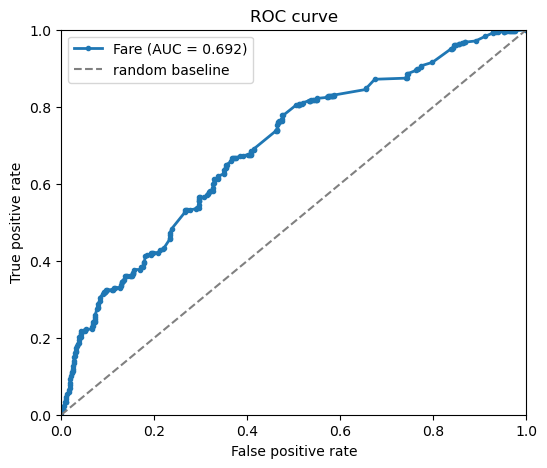

In [15]:
prep.plot_roc_curve(dataset.data["Fare"], dataset.data["Survived"], positive_class=1, label="Fare")

The ROC curve shows the tradeoff between true positive rate and false positive rate for all thresholds of `Fare`. A curve close to the diagonal would mean random ordering. Here the curve is above the diagonal, which matches the AUC value above 0.5.

<Axes: title={'center': 'ROC curves'}, xlabel='False positive rate', ylabel='True positive rate'>

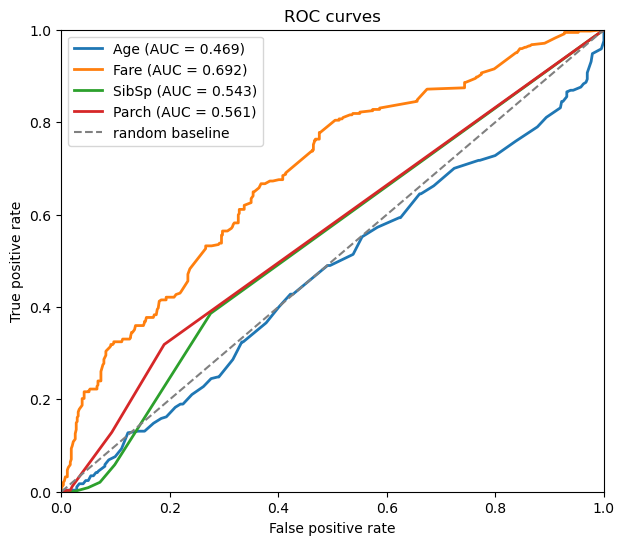

In [16]:
prep.plot_roc_curves(dataset.data, target="Survived", columns=["Age", "Fare", "SibSp", "Parch"], positive_class=1)

<Axes: title={'center': 'AUC by numerical attribute'}, xlabel='Attribute', ylabel='AUC'>

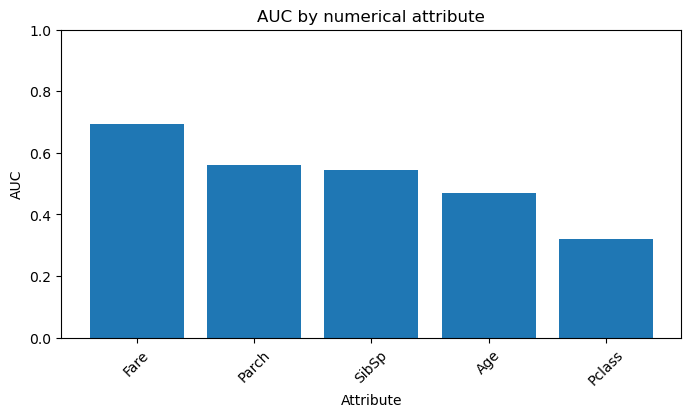

In [17]:
prep.compare_auc_values(dataset.data, target="Survived", positive_class=1)

The multi-ROC plot and the AUC comparison barplot answer related questions. The ROC plot shows the full threshold behavior of each variable, while the barplot gives a compact ranking by final AUC.

<Axes: title={'center': 'Distribution of Fare'}, xlabel='Fare', ylabel='Density'>

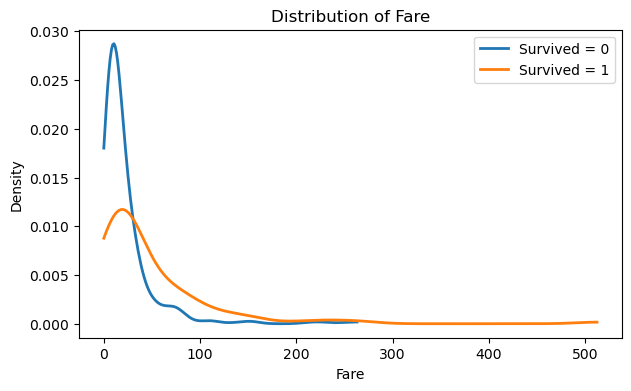

In [18]:
prep.plot_variable_distribution(dataset.data, variable="Fare", target="Survived", by_class=True)

<Axes: title={'center': 'Association matrix'}>

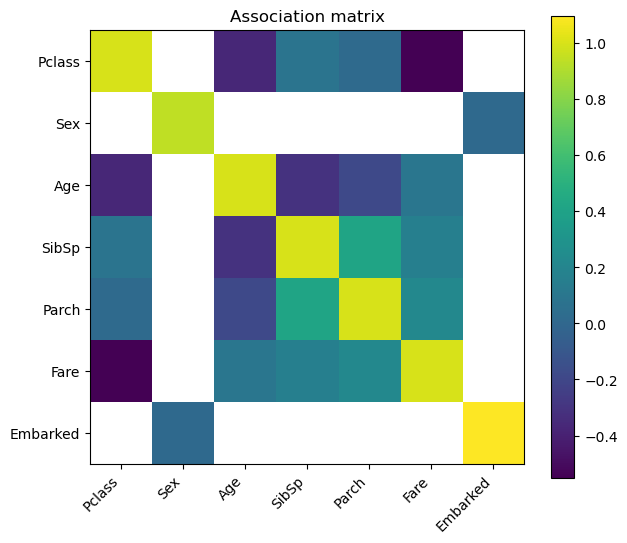

In [19]:
prep.plot_association_matrix(matrix)

The distribution plot helps compare the shape of one numerical variable across target classes. The matrix plot makes pairwise relationships easy to scan visually.

## Example 2: Real-world example

This final section uses a health dataset. Instead of using every function again, we apply a smaller set of relevant tools: target validation, missing-value/type inspection, descriptive comparison by class, AUC metrics, ROC curves, and distribution plots. 

This part also shows how we can directly use some of these functions from the dataset object.

In [20]:
diabetes_data = prep.DataPrepDataset.from_csv("data/diabetes/diabetes_prediction_dataset.csv", target="diabetes")
diabetes_data.data.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [21]:
diabetes_data.summary()

{'n_rows': 100000,
 'n_columns': 9,
 'variables':               variable pandas_dtype detected_type  missing_count  \
 0               gender       object   categorical              0   
 1                  age      float64     numerical              0   
 2         hypertension        int64        binary              0   
 3        heart_disease        int64        binary              0   
 4      smoking_history       object   categorical              0   
 5                  bmi      float64     numerical              0   
 6          HbA1c_level      float64     numerical              0   
 7  blood_glucose_level        int64     numerical              0   
 8             diabetes        int64        binary              0   
 
    missing_rate  unique_count  unique_rate  
 0           0.0             3      0.00003  
 1           0.0           102      0.00102  
 2           0.0             2      0.00002  
 3           0.0             2      0.00002  
 4           0.0             

In [23]:
diabetes_data.data["diabetes"].value_counts(normalize=True).rename("proportion")

diabetes
0    0.915
1    0.085
Name: proportion, dtype: float64

The diabetes dataset has 100,000 rows and no missing values. The target is binary, so it is valid for AUC/ROC analysis. The positive class is rare: about 8.5% of observations have `diabetes = 1`.

In [24]:
# The package AUC is implemented with pairwise comparisons for educational clarity.
# To keep this example fast, we use a reproducible balanced sample.
diabetes_sample = pd.concat(
    [
        diabetes_data.data[diabetes_data.data["diabetes"] == 0].sample(2000, random_state=7),
        diabetes_data.data[diabetes_data.data["diabetes"] == 1].sample(2000, random_state=7),
    ],
    ignore_index=True,
)

diabetes_sample = prep.DataPrepDataset(diabetes_sample, target="diabetes")

diabetes_metrics = diabetes_sample.metrics()
diabetes_metrics[diabetes_metrics["metric"] == "auc"].sort_values("value", ascending=False)

,attribute,metric,value
11,HbA1c_level,auc,0.836430
13,blood_glucose_level,auc,0.787996
2,age,auc,0.777467
9,bmi,auc,0.719874
4,hypertension,auc,0.600750
6,heart_disease,auc,0.567500


In this balanced sample, `HbA1c_level` is the strongest single numerical separator, followed by `blood_glucose_level`, `age`, and `bmi`. The binary medical-history variables are still informative, but their AUC values are lower as single-variable ranking scores.

<Axes: title={'center': 'ROC curves'}, xlabel='False positive rate', ylabel='True positive rate'>

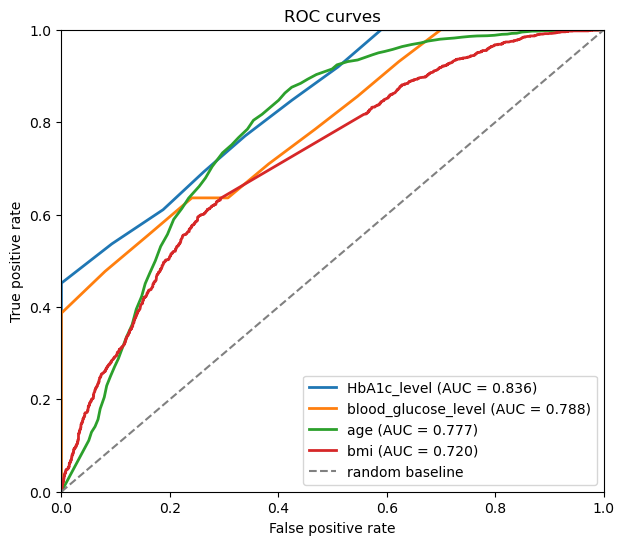

In [25]:
prep.plot_roc_curves(diabetes_sample.data, target="diabetes", columns=["HbA1c_level", "blood_glucose_level", "age", "bmi"], positive_class=1)

<Axes: title={'center': 'Distribution of HbA1c_level'}, xlabel='HbA1c_level', ylabel='Density'>

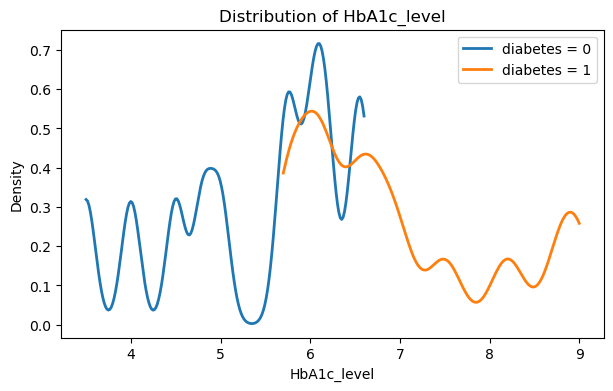

In [26]:
prep.plot_variable_distribution(diabetes_data.data, variable="HbA1c_level", target="diabetes", by_class=True)

<Axes: title={'center': 'Distribution of blood_glucose_level'}, xlabel='blood_glucose_level', ylabel='Density'>

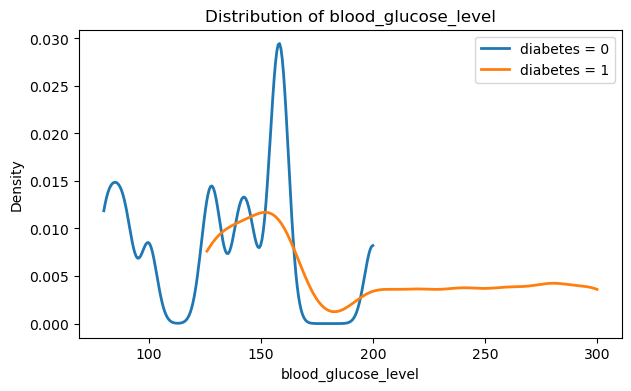

In [27]:
prep.plot_variable_distribution(diabetes_data.data, variable="blood_glucose_level", target="diabetes", by_class=True)

The ROC curves confirm the metric table: HbA1c and blood glucose are the most useful individual numerical variables in this quick analysis. The distribution plots explain why: the positive class is shifted toward higher HbA1c and glucose values. A practical preprocessing step for a later model would be to keep these variables, keep age and BMI as supporting predictors, and treat the class imbalance explicitly.